<a href="https://colab.research.google.com/github/Sebahstian/Learning-Projects/blob/main/crypto_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Crypto Price Prediction with Linear Regression in PyTorch

In [8]:
"""
A beginner-friendly end-to-end project:
  1. Fetch free crypto price data from CoinGecko (no API key needed)
  2. Build simple features
  3. Train a linear regression model in PyTorch
  4. Evaluate and plot results
"""

import requests
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 1. FETCH FREE DATA (CoinGecko - no API key required)

In [9]:
def fetch_prices(coin="bitcoin", days=365, currency="usd"):
    """Returns daily closing prices as a numpy array."""
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {"vs_currency": currency, "days": days, "interval": "daily"}
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    # data["prices"] is a list of [timestamp_ms, price]
    prices = np.array([p[1] for p in data["prices"]], dtype=np.float32)
    return prices


# Fallback: synthetic data if the network is unavailable, so the script
# always runs and you can study the modeling code.
def synthetic_prices(n=365):
    rng = np.random.default_rng(0)
    trend = np.linspace(20000, 60000, n)
    noise = rng.normal(0, 1500, n)
    season = 3000 * np.sin(np.linspace(0, 12 * np.pi, n))
    return (trend + season + noise).astype(np.float32)


try:
    prices = fetch_prices(coin="bitcoin", days=365)
    print(f"Fetched {len(prices)} days of real BTC prices.")
except Exception as e:
    print(f"Network fetch failed ({e}); using synthetic data instead.")
    prices = synthetic_prices()

Fetched 366 days of real BTC prices.


## 2. BUILD FEATURES

In [10]:
# Goal: predict tomorrow's price from a window of the last N days' prices.
WINDOW = 5  # number of past days used as features

X, y = [], []
for i in range(len(prices) - WINDOW):
    X.append(prices[i : i + WINDOW])      # past WINDOW prices -> features
    y.append(prices[i + WINDOW])          # next day price     -> target

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

# Scale features and target (linear regression trains far better on scaled data)
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

# Train / test split (shuffle off to respect time ordering is optional;
# here we keep it simple with a random split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)


##3. DEFINE THE LINEAR REGRESSION MODEL

In [11]:
class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # A single linear layer == linear regression: y = Wx + b
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)


model = LinearRegression(n_features=WINDOW)
criterion = nn.MSELoss()                       # mean squared error
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## 4. TRAIN

In [12]:
EPOCHS = 500
losses = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train)
    loss = criterion(preds, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{EPOCHS} | Train MSE: {loss.item():.4f}")

Epoch   50/500 | Train MSE: 0.0580
Epoch  100/500 | Train MSE: 0.0326
Epoch  150/500 | Train MSE: 0.0286
Epoch  200/500 | Train MSE: 0.0274
Epoch  250/500 | Train MSE: 0.0267
Epoch  300/500 | Train MSE: 0.0260
Epoch  350/500 | Train MSE: 0.0254
Epoch  400/500 | Train MSE: 0.0249
Epoch  450/500 | Train MSE: 0.0243
Epoch  500/500 | Train MSE: 0.0238


##5. EVALUATE

In [13]:
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test)
    test_loss = criterion(test_preds_scaled, y_test).item()

# Invert scaling to see predictions in real dollars
test_preds = y_scaler.inverse_transform(test_preds_scaled.numpy())
y_test_real = y_scaler.inverse_transform(y_test.numpy())

mae = np.mean(np.abs(test_preds - y_test_real))
print(f"\nTest MSE (scaled): {test_loss:.4f}")
print(f"Test MAE (USD):    ${mae:,.2f}")



Test MSE (scaled): 0.0173
Test MAE (USD):    $1,788.52


##6. PLOT

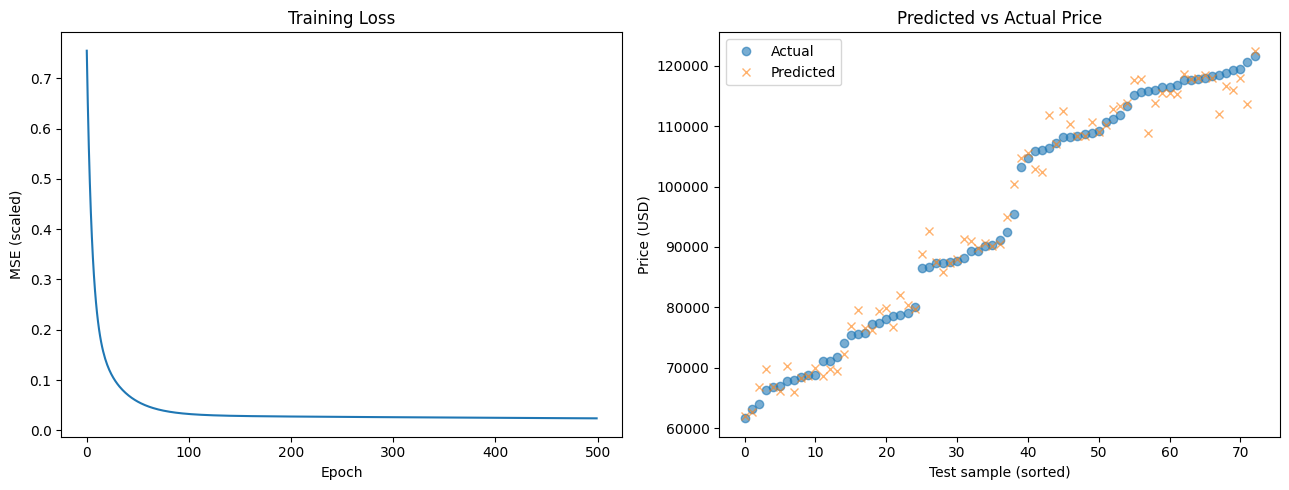

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (scaled)")

# Sort test points for a cleaner predicted-vs-actual line
order = np.argsort(y_test_real.flatten())
ax2.plot(y_test_real[order], label="Actual", marker="o", linestyle="", alpha=0.6)
ax2.plot(test_preds[order], label="Predicted", marker="x", linestyle="", alpha=0.6)
ax2.set_title("Predicted vs Actual Price")
ax2.set_xlabel("Test sample (sorted)")
ax2.set_ylabel("Price (USD)")
ax2.legend()

plt.tight_layout()